
# Seepage vs Δh — Pooled + Per-Event Fits (Linear, Power, Offset) with Visitor-Head Option

This notebook provides a concise but **complete** wrap‑up of the seepage–head models, while **keeping**:
- **Per-event fits** (summary table and quick distributions)
- **Visitor‑head power model** (optional; used if such a column is available)
- **Offset-power** form

## Models
- **Linear (zero intercept):** \( S = K\,\Delta h \)
- **Power:** \( S = K\,(\Delta h)^b \)
- **Offset-power:** \( S = K\,(\Delta h + c)^b \), with \( K>0,\; b\in[0.5,2],\; c\ge 0 \)

We fit **pooled** models and, when `event` is available, **per-event** models (minimum sample size per event is configurable).
We compare models with centered \(R^2\), **AIC** and **ΔAIC**. We also compute **bootstrap 95% CIs** for pooled parameters.


In [11]:

# --- Imports & configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.optimize import minimize

# Try to use rich display for tables if available
try:
    from ace_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

np.random.seed(42)

# Minimal plot prefs
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Paths and knobs
DATA_PATH = Path("../data/processed/pooled_event_df.csv")  # Adjust as needed
MIN_N_PER_EVENT = 12   # only fit per-event models if an event has at least this many rows
BOOTSTRAP_B = 500      # Increase to 1000 for publication; 500 is fine for "good enough"



## 1) Load data, apply a single filter, and detect optional columns

**Required columns:** `delta_h`, `seepage`  
**Optional columns:** `event`, **visitor-head** (one of: `delta_h_visitor`, `visitor_head`, `delta_h_vis`)

We apply a single, fixed QC filter: nonnegative `delta_h` and `seepage`. Feel free to add your domain-specific filters here.


In [12]:

# --- Load ---
df = pd.read_csv(DATA_PATH)

# Ensure numeric types; drop NA
for col in ["delta_h", "seepage"]:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' is missing from {DATA_PATH}")
df["delta_h"] = pd.to_numeric(df["delta_h"], errors="coerce")
df["seepage"] = pd.to_numeric(df["seepage"], errors="coerce")
df = df.dropna(subset=["delta_h", "seepage"]).copy()

# Single QC: keep nonnegative values
df = df.query("delta_h >= 0 and seepage >= 0").copy()

# Detect event column
has_event = "event" in df.columns

# Detect visitor-head column
visitor_candidates = [c for c in ["delta_h_visitor", "visitor_head", "delta_h_vis"] if c in df.columns]
visitor_col = visitor_candidates[0] if visitor_candidates else None

# Report sample size
n = len(df)
nevents = df["event"].nunique() if has_event else np.nan
print(f"N = {n} rows" + (f", events = {nevents}" if has_event else ""))
if visitor_col:
    print(f"Visitor-head driver detected: '{visitor_col}'")
else:
    print("No visitor-head driver column found (optional).")

# Extract arrays for main driver
x_main = df["delta_h"].to_numpy()
y = df["seepage"].to_numpy()

# Optional visitor-head driver
x_vis = df[visitor_col].to_numpy() if visitor_col else None


N = 493 rows, events = 56
No visitor-head driver column found (optional).



## 2) Models & fitting utilities

We define the three main model forms and objective functions (SSE). For offset-power, we bound \(c\) to \([0, c_{\max}]\)
with \(c_{\max}\) taken as the 95th percentile of the driver to avoid degenerate fits.


In [13]:

# --- Model functions ---
def model_linear(params, x):
    K, = params
    return K * x

def model_power(params, x):
    K, b = params
    x_pos = np.clip(x, 0, None)
    return K * np.power(x_pos, b)

def model_offset_power(params, x, cmax):
    K, b, c = params
    x_pos = np.clip(x, 0, None) + c
    return K * np.power(x_pos, b)

# --- SSE objectives ---
def sse_linear(params, x, y):
    yhat = model_linear(params, x)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat) ** 2)

def sse_power(params, x, y):
    K, b = params
    if K <= 0 or not np.isfinite(b):
        return np.inf
    yhat = model_power(params, x)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat) ** 2)

def sse_offset_power(params, x, y, cmax):
    K, b, c = params
    if K <= 0 or not np.isfinite(b) or c < 0 or c > cmax:
        return np.inf
    yhat = model_offset_power(params, x, cmax)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat) ** 2)

# --- Metrics ---
def r2_centered(y, yhat):
    resid = y - yhat
    sse = np.sum(resid**2)
    tss = np.sum((y - y.mean())**2)
    return 1.0 - sse / tss if tss > 0 else np.nan

def aic_gaussian(y, yhat, k_params):
    n = len(y)
    sse = np.sum((y - yhat)**2)
    sigma2 = sse / n
    return n * np.log(sigma2) + 2 * k_params

# --- Fitting wrappers ---
def fit_linear(x, y):
    den = np.sum(x * x)
    K = np.sum(x * y) / den if den > 0 else np.nan
    yhat = model_linear([K], x)
    return {"params": (K,), "yhat": yhat, "R2": r2_centered(y, yhat), "AIC": aic_gaussian(y, yhat, 1)}

def fit_power(x, y, K0=None, b0=1.0):
    if K0 is None:
        K0 = (y.mean() / (x.mean() + 1e-12))
    res = minimize(lambda p: sse_power(p, x, y),
                   x0=np.array([max(K0, 1e-12), b0], dtype=float),
                   method="L-BFGS-B", bounds=[(1e-12, None), (0.5, 2.0)])
    K, b = res.x
    yhat = model_power((K, b), x)
    return {"params": (K, b), "yhat": yhat, "R2": r2_centered(y, yhat), "AIC": aic_gaussian(y, yhat, 2)}

def fit_offset_power(x, y, K0=None, b0=1.0, c0=None):
    if K0 is None:
        K0 = (y.mean() / (x.mean() + 1e-12))
    cmax = float(np.nanpercentile(x, 95)) if np.nanmax(x) > 0 else 1.0
    if c0 is None:
        c0 = 0.1 * cmax
    res = minimize(lambda p: sse_offset_power(p, x, y, cmax),
                   x0=np.array([max(K0, 1e-12), b0, max(c0, 0.0)], dtype=float),
                   method="L-BFGS-B", bounds=[(1e-12, None), (0.5, 2.0), (0.0, cmax)])
    K, b, c = res.x
    yhat = model_offset_power((K, b, c), x, cmax)
    return {"params": (K, b, c), "yhat": yhat, "R2": r2_centered(y, yhat), "AIC": aic_gaussian(y, yhat, 3), "cmax": cmax}

def delta_aic(aics):
    # Return dict of ΔAIC = AIC - min(AIC)
    amin = min(aics.values())
    return {k: v - amin for k, v in aics.items()}



## 3) Pooled fits — main driver (`delta_h`)

We fit Linear, Power, and Offset‑Power models on the pooled data.


In [14]:

# --- Pooled fits (main) ---
res_lin_main = fit_linear(x_main, y)
K_lin, = res_lin_main["params"]

res_pow_main = fit_power(x_main, y, K0=K_lin, b0=1.0)
K_pow, b_pow = res_pow_main["params"]

res_off_main = fit_offset_power(x_main, y, K0=K_lin, b0=1.0, c0=None)
K_off, b_off, c_off = res_off_main["params"]

# ΔAIC summary
aics = {
    "Linear": res_lin_main["AIC"],
    "Power": res_pow_main["AIC"],
    "Offset-Power": res_off_main["AIC"],
}
dAIC = delta_aic(aics)

pooled_main_tbl = pd.DataFrame([
    {"Model": "Linear", "K": K_lin, "b": np.nan, "c": np.nan, "R2": res_lin_main["R2"], "AIC": res_lin_main["AIC"], "ΔAIC": dAIC["Linear"]},
    {"Model": "Power", "K": K_pow, "b": b_pow, "c": np.nan, "R2": res_pow_main["R2"], "AIC": res_pow_main["AIC"], "ΔAIC": dAIC["Power"]},
    {"Model": "Offset-Power", "K": K_off, "b": b_off, "c": c_off, "R2": res_off_main["R2"], "AIC": res_off_main["AIC"], "ΔAIC": dAIC["Offset-Power"]},
])

# Display pooled summary
if display_dataframe_to_user:
    display_dataframe_to_user("Pooled main-driver fit summary", pooled_main_tbl)
else:
    display(pooled_main_tbl)

print("Preferred pooled model (main driver) by AIC:", min(aics, key=aics.get), "with ΔAIC:", {k: round(v,1) for k,v in dAIC.items()})


,Model,K,b,c,R2,AIC,ΔAIC
0,Linear,1.083792,NaN,NaN,0.369719,-353.459706,6.533657
1,Power,0.970264,1.183239,NaN,0.377016,-357.200362,2.793001
2,Offset-Power,0.221453,2.000000,1.144288,0.383043,-359.993363,0.000000


Preferred pooled model (main driver) by AIC: Offset-Power with ΔAIC: {'Linear': 6.5, 'Power': 2.8, 'Offset-Power': 0.0}



## 4) Pooled fits — **visitor-head** driver (optional)

If a visitor-head column is present (detected automatically), we repeat pooled fits for the **power** and **offset-power** forms.


In [15]:

pooled_visitor_tbl = None
if x_vis is not None:
    # Fit visitor-driver power & offset-power
    res_pow_vis = fit_power(x_vis, y, K0=None, b0=1.0)
    Kp_v, bp_v = res_pow_vis["params"]

    res_off_vis = fit_offset_power(x_vis, y, K0=None, b0=1.0, c0=None)
    Ko_v, bo_v, co_v = res_off_vis["params"]

    aics_vis = {"Power (visitor)": res_pow_vis["AIC"], "Offset-Power (visitor)": res_off_vis["AIC"]}
    dAIC_vis = delta_aic(aics_vis)

    pooled_visitor_tbl = pd.DataFrame([
        {"Model": "Power (visitor)", "K": Kp_v, "b": bp_v, "c": np.nan, "R2": res_pow_vis["R2"], "AIC": res_pow_vis["AIC"], "ΔAIC": dAIC_vis["Power (visitor)"]},
        {"Model": "Offset-Power (visitor)", "K": Ko_v, "b": bo_v, "c": co_v, "R2": res_off_vis["R2"], "AIC": res_off_vis["AIC"], "ΔAIC": dAIC_vis["Offset-Power (visitor)"]},
    ])

    if display_dataframe_to_user:
        display_dataframe_to_user("Pooled visitor-head fit summary", pooled_visitor_tbl)
    else:
        display(pooled_visitor_tbl)

    print("Preferred pooled model (visitor driver) by AIC:", min(aics_vis, key=aics_vis.get), "with ΔAIC:", {k: round(v,1) for k,v in dAIC_vis.items()})
else:
    print("Skipping visitor-head pooled fits (no visitor-head column detected).")


Skipping visitor-head pooled fits (no visitor-head column detected).



## 5) Bootstrap 95% CIs for pooled parameters

Residual bootstrap with \(B=500\) by default (adjust `BOOTSTRAP_B` as needed). We compute CIs for all pooled models.


In [16]:

def bootstrap_pooled(x, y, fit_fn, yhat_base, k_params, B=BOOTSTRAP_B, rng_seed=123):
    rng = np.random.default_rng(rng_seed)
    resid = y - yhat_base
    params_list = []

    for _ in range(B):
        eps = rng.choice(resid, size=len(resid), replace=True)
        y_star = yhat_base + eps
        y_star = np.clip(y_star, 1e-12, None)  # guard against negatives
        res = fit_fn(x, y_star)
        params_list.append(res["params"])

    params_arr = np.array([np.array(p) for p in params_list], dtype=float)
    return np.nanpercentile(params_arr, [2.5, 50, 97.5], axis=0)  # lo, med, hi

# Linear
ci_lin = bootstrap_pooled(x_main, y, lambda X,Y: fit_linear(X,Y), res_lin_main["yhat"], k_params=1)
# Power (main)
ci_pow = bootstrap_pooled(x_main, y, lambda X,Y: fit_power(X,Y, K0=K_lin, b0=1.0), res_pow_main["yhat"], k_params=2)
# Offset-Power (main)
ci_off = bootstrap_pooled(x_main, y, lambda X,Y: fit_offset_power(X,Y, K0=K_lin, b0=1.0, c0=c_off), res_off_main["yhat"], k_params=3)

# Optional visitor
ci_pow_vis = ci_off_vis = None
if x_vis is not None:
    ci_pow_vis = bootstrap_pooled(x_vis, y, lambda X,Y: fit_power(X,Y, K0=None, b0=1.0), fit_power(x_vis, y)["yhat"], k_params=2)
    ci_off_vis = bootstrap_pooled(x_vis, y, lambda X,Y: fit_offset_power(X,Y, K0=None, b0=1.0, c0=None), fit_offset_power(x_vis, y)["yhat"], k_params=3)

def format_ci_row(name, est, ci_arr):
    est = np.array(est, dtype=float)
    lo, med, hi = ci_arr
    d = {"Model": name}
    for i, p in enumerate(est):
        d[f"param{i+1}_est"] = p
        d[f"param{i+1}_lo"]  = lo[i]
        d[f"param{i+1}_hi"]  = hi[i]
    return d

rows = [
    format_ci_row("Linear (K)", (K_lin,), ci_lin),
    format_ci_row("Power (K,b)", (K_pow, b_pow), ci_pow),
    format_ci_row("Offset-Power (K,b,c)", (K_off, b_off, c_off), ci_off),
]

if x_vis is not None:
    # Use the earlier fitted values to populate estimates in the table
    rows.append(format_ci_row("Power (visitor K,b)", (pooled_visitor_tbl.loc[pooled_visitor_tbl['Model']=="Power (visitor)","K"].values[0],
                                                      pooled_visitor_tbl.loc[pooled_visitor_tbl['Model']=="Power (visitor)","b"].values[0]),
                              ci_pow_vis))
    rows.append(format_ci_row("Offset-Power (visitor K,b,c)", (pooled_visitor_tbl.loc[pooled_visitor_tbl['Model']=="Offset-Power (visitor)","K"].values[0],
                                                               pooled_visitor_tbl.loc[pooled_visitor_tbl['Model']=="Offset-Power (visitor)","b"].values[0],
                                                               pooled_visitor_tbl.loc[pooled_visitor_tbl['Model']=="Offset-Power (visitor)","c"].values[0]),
                              ci_off_vis))

ci_tbl = pd.DataFrame(rows)
if display_dataframe_to_user:
    display_dataframe_to_user("Pooled parameter bootstrap 95% CIs", ci_tbl)
else:
    display(ci_tbl)


,Model,param1_est,param1_lo,param1_hi,param2_est,param2_lo,param2_hi,param3_est,param3_lo,param3_hi
0,Linear (K),1.083792,1.043151,1.111113,NaN,NaN,NaN,NaN,NaN,NaN
1,"Power (K,b)",0.970264,0.891421,1.083569,1.183239,1.018834,1.306245,NaN,NaN,NaN
2,"Offset-Power (K,b,c)",0.221453,0.180006,1.035856,2.000000,1.104167,2.000000,1.144288,0.0,1.470681



## 6) Figures (pooled)

- Scatter \(S\) vs \( \Delta h \) with Linear, Power, and Offset‑Power fits
- Residuals vs fitted for the selected (AIC‑best) main‑driver model


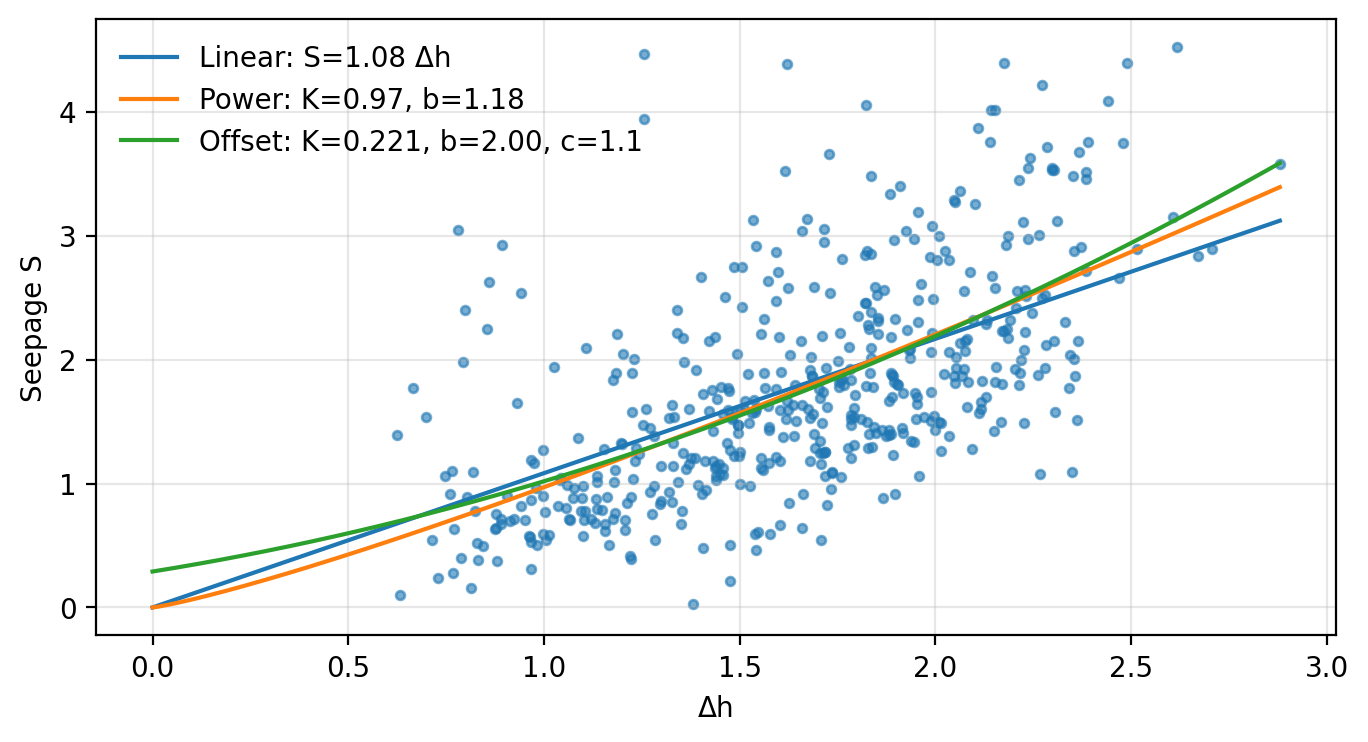

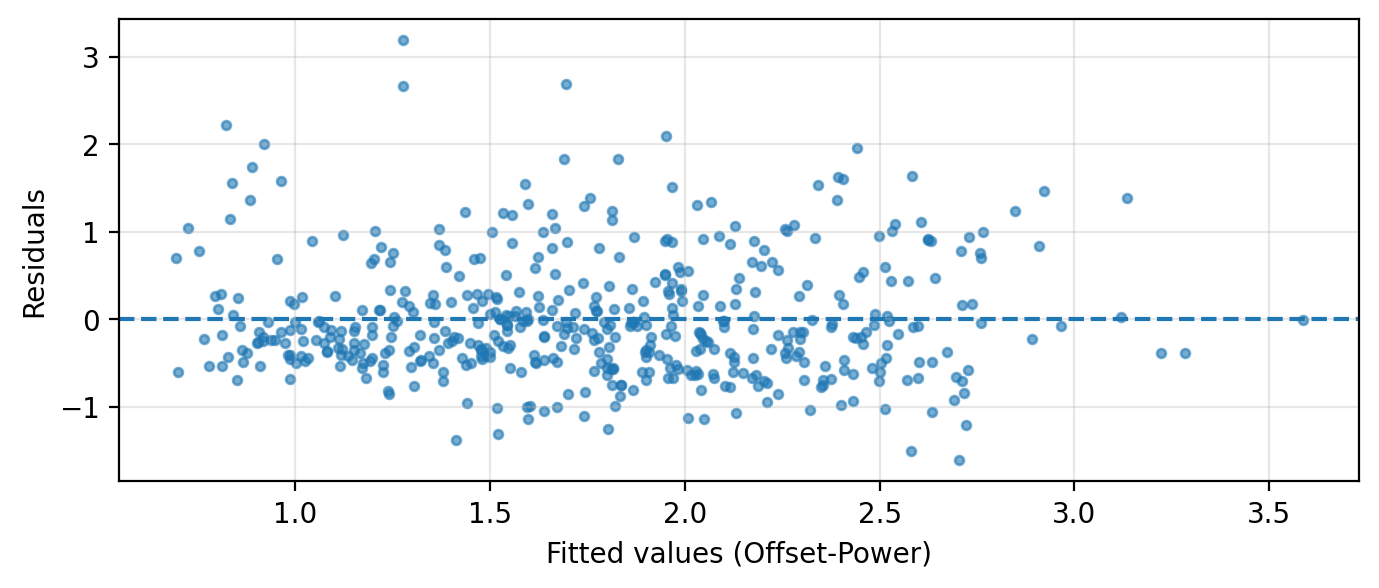

In [17]:

# Pooled scatter with fits (main driver)
fig = plt.figure(figsize=(8,4))
ax = plt.gca()
ax.scatter(x_main, y, s=10, alpha=0.6)
xs = np.linspace(0, np.nanmax(x_main), 200)
ax.plot(xs, model_linear((K_lin,), xs), label=f"Linear: S={K_lin:.3g} Δh")
ax.plot(xs, model_power((K_pow, b_pow), xs), label=f"Power: K={K_pow:.3g}, b={b_pow:.2f}")
ax.plot(xs, model_offset_power((K_off, b_off, c_off), xs, res_off_main.get('cmax', np.nan)), label=f"Offset: K={K_off:.3g}, b={b_off:.2f}, c={c_off:.2g}")
ax.set_xlabel("Δh")
ax.set_ylabel("Seepage S")
ax.legend(frameon=False)
plt.show()

# Residuals vs fitted for AIC-best main model
best_main = min(aics, key=aics.get)
yhat_best = {"Linear": res_lin_main["yhat"],
             "Power": res_pow_main["yhat"],
             "Offset-Power": res_off_main["yhat"]}[best_main]

fig = plt.figure(figsize=(8,3))
ax = plt.gca()
ax.scatter(yhat_best, y - yhat_best, s=10, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel(f"Fitted values ({best_main})")
ax.set_ylabel("Residuals")
plt.show()



## 7) Per‑event fits (main driver)
We fit Linear, Power, and Offset‑Power models **per event** when there are at least `MIN_N_PER_EVENT` points.
A summary table is provided, along with distributions of \(b\) and ΔAIC across events.


,event,n,best_model,K_linear,K_power,b_power,K_offset,b_offset,c_offset,R2_linear,R2_power,R2_offset,AIC_linear,AIC_power,AIC_offset,ΔAIC_linear,ΔAIC_power,ΔAIC_offset
0,0,28,Linear,0.787971,0.886482,0.801638,0.886482,0.801637,0.000000,0.386280,0.403613,0.403613,-54.168863,-52.971010,-50.971010,0.000000,1.197854,3.197854
5,5,17,Linear,1.200827,0.977272,1.404239,0.977272,1.404240,0.000000,0.412687,0.449822,0.449822,-11.594269,-10.704645,-8.704645,0.000000,0.889624,2.889624
7,7,17,Linear,0.544264,0.541423,1.068708,0.541422,1.068727,0.000000,0.276830,0.277865,0.277865,-61.837033,-59.861366,-57.861366,0.000000,1.975668,3.975668
9,9,22,Linear,1.657023,1.722278,0.940482,1.722278,0.940482,0.000000,0.831856,0.834484,0.834484,-54.271121,-52.617643,-50.617643,0.000000,1.653478,3.653478
10,10,21,Linear,1.411487,1.244238,1.178378,0.284198,1.992287,1.144344,0.670172,0.680918,0.682955,-25.394176,-24.089814,-22.224303,0.000000,1.304363,3.169873
13,15,12,Linear,0.718862,0.761483,0.868662,0.761483,0.868662,0.000000,0.250496,0.255344,0.255344,-29.599194,-27.677062,-25.677062,0.000000,1.922131,3.922131
1,1,25,Power,0.946948,0.751112,1.421263,0.751112,1.421263,0.000000,0.640534,0.690871,0.690871,-72.530524,-74.302064,-72.302064,1.771540,0.000000,2.000000
2,2,28,Power,1.018414,0.823784,1.292700,0.230480,2.000000,0.941992,0.724660,0.751319,0.754375,-54.778731,-55.630144,-53.976365,0.851413,0.000000,1.653779
3,3,23,Power,0.897288,1.051391,0.500000,1.036348,0.500000,0.037046,0.047937,0.209304,0.208919,-47.130607,-49.402097,-47.390902,2.271490,0.000000,2.011194
4,4,21,Power,1.091831,0.848863,1.380901,0.848863,1.380901,0.000000,0.776632,0.834423,0.834423,-38.138147,-42.425198,-40.425198,4.287051,0.000000,2.000000


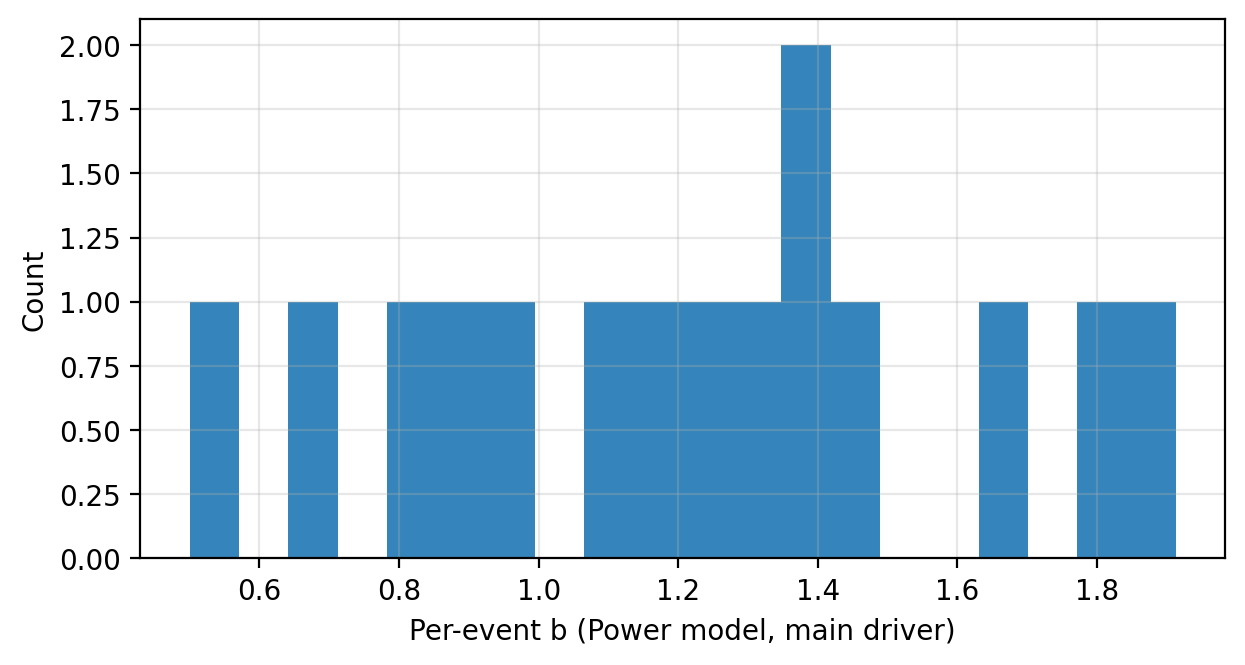

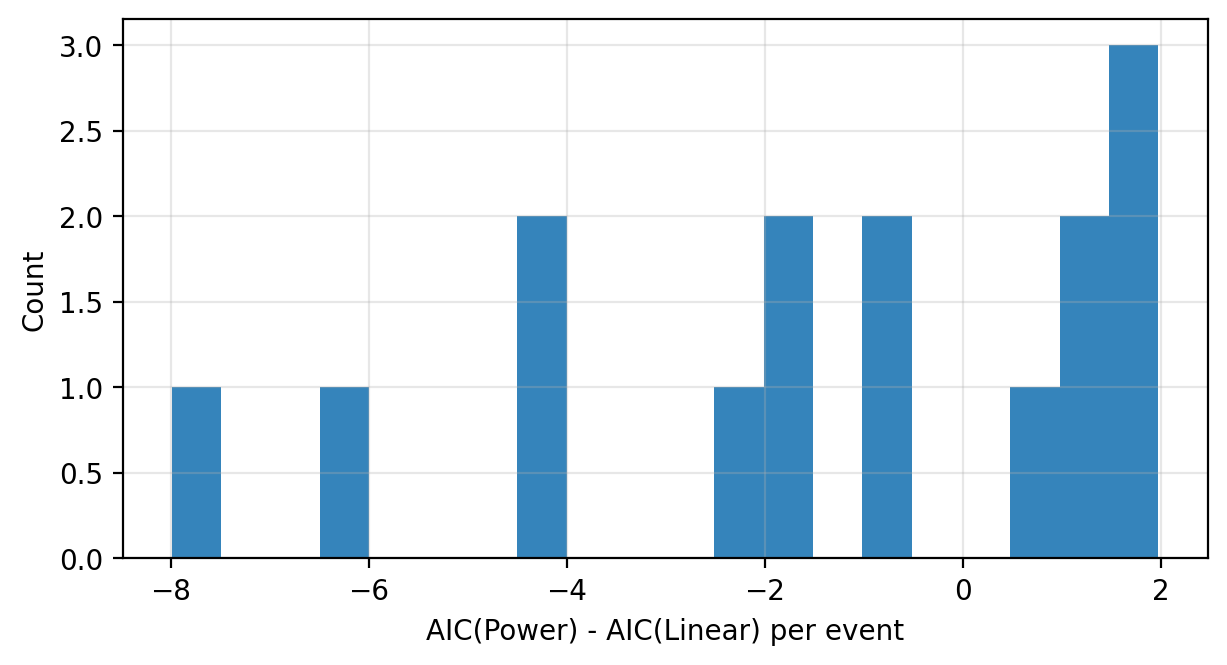

In [18]:

per_event_tbl = None
if "event" in df.columns:
    rows = []
    grouped = df.groupby("event")
    for eid, g in grouped:
        if len(g) < MIN_N_PER_EVENT:
            continue
        x_e = g["delta_h"].to_numpy()
        y_e = g["seepage"].to_numpy()

        # Fit three models
        rL = fit_linear(x_e, y_e)
        rP = fit_power(x_e, y_e, K0=None, b0=1.0)
        rO = fit_offset_power(x_e, y_e, K0=None, b0=1.0, c0=None)

        a = {"Linear": rL["AIC"], "Power": rP["AIC"], "Offset-Power": rO["AIC"]}
        d = delta_aic(a)
        best = min(a, key=a.get)

        K_L, = rL["params"]
        K_P, b_P = rP["params"]
        K_O, b_O, c_O = rO["params"]

        rows.append({
            "event": eid,
            "n": len(g),
            "best_model": best,
            "K_linear": K_L,
            "K_power": K_P, "b_power": b_P,
            "K_offset": K_O, "b_offset": b_O, "c_offset": c_O,
            "R2_linear": rL["R2"], "R2_power": rP["R2"], "R2_offset": rO["R2"],
            "AIC_linear": a["Linear"], "AIC_power": a["Power"], "AIC_offset": a["Offset-Power"],
            "ΔAIC_linear": d["Linear"], "ΔAIC_power": d["Power"], "ΔAIC_offset": d["Offset-Power"],
        })

    per_event_tbl = pd.DataFrame(rows).sort_values(["best_model","event"])

    title = f"Per-event fit summary (min n={MIN_N_PER_EVENT})"
    if display_dataframe_to_user:
        display_dataframe_to_user(title, per_event_tbl)
    else:
        display(per_event_tbl.head(20))  # don't flood output if many events

    # Distribution of exponents and ΔAIC across events
    if not per_event_tbl.empty:
        # b (power) distribution
        fig = plt.figure(figsize=(7,3.5))
        ax = plt.gca()
        ax.hist(per_event_tbl["b_power"].dropna().to_numpy(), bins=20, alpha=0.9)
        ax.set_xlabel("Per-event b (Power model, main driver)")
        ax.set_ylabel("Count")
        plt.show()

        # ΔAIC (Power vs Linear)
        fig = plt.figure(figsize=(7,3.5))
        ax = plt.gca()
        d_power = per_event_tbl["ΔAIC_power"].to_numpy()  # ΔAIC = AIC_power - AIC_best; but here it is vs min(AIC) per-event
        # For more intuitive comparison vs Linear, compute AIC_power - AIC_linear
        diff = per_event_tbl["AIC_power"].to_numpy() - per_event_tbl["AIC_linear"].to_numpy()
        ax.hist(diff, bins=20, alpha=0.9)
        ax.set_xlabel("AIC(Power) - AIC(Linear) per event")
        ax.set_ylabel("Count")
        plt.show()
else:
    print("Per-event fits skipped (no 'event' column).")



## 8) (Optional) Per‑event visitor‑head power fits

If a visitor‑head driver exists, we fit the **Power** model per‑event as a quick sensitivity check and compare to main‑driver Power.


In [19]:

per_event_vis_tbl = None
if "event" in df.columns and x_vis is not None:
    rows = []
    for eid, g in df.groupby("event"):
        if len(g) < MIN_N_PER_EVENT:
            continue
        xv = g[visitor_col].to_numpy()
        yv = g["seepage"].to_numpy()
        rPv = fit_power(xv, yv, K0=None, b0=1.0)
        Kpv, bpv = rPv["params"]
        rows.append({"event": eid, "n": len(g), "K_power_vis": Kpv, "b_power_vis": bpv, "R2_power_vis": rPv["R2"], "AIC_power_vis": rPv["AIC"]})
    per_event_vis_tbl = pd.DataFrame(rows).sort_values("event")

    # Merge with main per-event Power for quick comparison (if available)
    if 'per_event_tbl' in globals() and per_event_tbl is not None and not per_event_tbl.empty:
        comp = per_event_tbl[["event","n","K_power","b_power","R2_power","AIC_power"]].merge(
            per_event_vis_tbl, on=["event","n"], how="inner", suffixes=("_main","_visitor")
        )
        if display_dataframe_to_user:
            display_dataframe_to_user("Per-event Power: main vs visitor-head comparison", comp)
        else:
            display(comp.head(20))

        # Histogram of ΔAIC (visitor vs main) where both available
        fig = plt.figure(figsize=(7,3.5))
        ax = plt.gca()
        ax.hist((comp["AIC_power_vis"] - comp["AIC_power"]).to_numpy(), bins=20, alpha=0.9)
        ax.set_xlabel("AIC(Power, visitor) - AIC(Power, main)")
        ax.set_ylabel("Count")
        plt.show()
    else:
        title = "Per-event Power (visitor)"
        if display_dataframe_to_user:
            display_dataframe_to_user(title, per_event_vis_tbl)
        else:
            display(per_event_vis_tbl.head(20))
else:
    print("Per-event visitor-head fits skipped (no visitor-head or no 'event').")


Per-event visitor-head fits skipped (no visitor-head or no 'event').



## 9) Plain‑English conclusion (auto‑filled)

This cell prints a concise conclusion referencing pooled ΔAIC and per‑event patterns.


In [10]:

# Determine pooled winner for main driver
pooled_winner = min(aics, key=aics.get)
dAIC_print = {k: round(v, 1) for k, v in dAIC.items()}

lines = []
lines.append(f"Pooled comparison (main driver): AIC -> { {k: round(v,1) for k,v in aics.items()} } (ΔAIC vs best: {dAIC_print}).")
lines.append(f"Preferred pooled model (main driver): **{pooled_winner}**.")

if visitor_col and x_vis is not None:
    lines.append("Visitor-head pooled fits were evaluated; see the table for AIC and R².")

if "event" in df.columns and per_event_tbl is not None and not per_event_tbl.empty:
    frac_power_better = float((per_event_tbl['AIC_power'] < per_event_tbl['AIC_linear']).mean())
    frac_offset_better = float((per_event_tbl['AIC_offset'] < per_event_tbl['AIC_linear']).mean())
    lines.append(f"Per-event, Power beats Linear in ~{100*frac_power_better:.1f}% of events; "
                 f"Offset-Power beats Linear in ~{100*frac_offset_better:.1f}% of events (threshold: AIC).")
    # b ~ 1?
    b_med = float(np.nanmedian(per_event_tbl["b_power"].to_numpy()))
    lines.append(f"The median per-event exponent for the Power model is b ≈ {b_med:.2f}.")

print("\n".join(lines))


Pooled comparison (main driver): AIC -> {'Linear': -353.5, 'Power': -357.2, 'Offset-Power': -360.0} (ΔAIC vs best: {'Linear': 6.5, 'Power': 2.8, 'Offset-Power': 0.0}).
Preferred pooled model (main driver): **Offset-Power**.
Per-event, Power beats Linear in ~60.0% of events; Offset-Power beats Linear in ~33.3% of events (threshold: AIC).
The median per-event exponent for the Power model is b ≈ 1.26.



## Appendix
- Increase `BOOTSTRAP_B` to 1000 for final CI stability if runtime permits.
- If offset-power fits drift toward large `c`, consider tightening the upper bound for `c` (e.g., 80th percentile).
- Add domain-specific QC filters in Section 1 (e.g., sampling windows, tide phases) *once* and keep them fixed.
